In [2]:
# ── 라이브러리 import (한 번만 실행; 이후 모든 셀이 이 이름을 그대로 사용) ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, roc_curve

# ── 0. 환경 설정 ──────────────────────────────────────────────
# (1) 라이브러리 import — 이후 모든 셀이 여기서 불러온 이름을 그대로 사용

# 그래프 기본 스타일(선택)
sns.set_theme(style="whitegrid")

# (2) 시드 설정 — 본인 학번 뒷 4자리를 넣으세요 (예: 2026-12345 → 2345)
MY_SEED = 1352               # 학번 뒷 4자리 입력 완료
np.random.seed(MY_SEED)       # MY_SEED로 난수 생성기 고정

# (3) 데이터 로드 — 공개 URL 우선, 실패 시 업로드한 로컬 파일로 대체
# 데이터 로드: 공개 URL에서 바로 읽습니다(업로드 불필요). 실패 시 업로드한 로컬 파일 사용.
DATA_URL = "https://raw.githubusercontent.com/GauravPadawe/Framingham-Heart-Study/master/framingham.csv"
try:
    df = pd.read_csv(DATA_URL)
except Exception:
    df = pd.read_csv("framingham.csv")   # Colab: 좌측 파일 탭에 framingham.csv 업로드 후

# 이후 섹션 전체가 공유하는 수치형 열 목록
num_cols = ["age", "sysBP", "diaBP", "totChol", "BMI", "glucose", "heartRate"]

# 로드 확인
print("데이터 크기 (행, 열):", df.shape)          # 기대: (4240, 16)
print("MY_SEED =", MY_SEED)
print("\n[첫 3행]")
print(df.head(3))
print("\n[열별 결측치 개수 (0이 아닌 것만)]")
print(df.isna().sum()[df.isna().sum() > 0])       # 결측치 확인

데이터 크기 (행, 열): (4240, 16)
MY_SEED = 1352

[첫 3행]
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   

   TenYearCHD  
0           0  
1           0  
2           0  

[열별 결측치 개수 (0이 아닌 것만)]
education     105
cigsPerDay     29
BPMeds         53
totChol        50
BMI            19
heartRate       1
glucose       388
dtype: int64


**Q0. 데이터를 제대로 불렀는지 확인해 봅시다.**

1. `df.shape`는 무엇인가요? 행(참가자) 수와 열(변수) 수를 **본인이 본 실제 숫자**로 적으세요.

참가자 수 4240명, 변수 16개

2. **결측이 가장 많은 열**은 무엇이고 몇 개인가요? Framingham은 결측이 있어 뒤 섹션에서 `dropna()` 처리가 필요하니, 어떤 열이 문제일지 미리 봐 두세요.

glucolse, 388개

3. `MY_SEED`를 다른 값으로 바꿔 이 셀을 다시 실행하면 `df.shape`가 달라질까요? 왜 그런지 한 줄로 설명하세요.

달라지지 않음. 난수 시드는 무작위 추첨/분할 절차에만 영향을 줄 뿐, 저장된 파일에서 데이터를 그대로 불러오는 행위에는 영향을 주지 않음.

> 힌트(3번): 시드는 *무작위 절차*(시뮬레이션·표본추출)에만 영향을 줍니다. 파일에서 데이터를 그대로 읽어오는 것은 무작위가 아닙니다.


In [3]:
# 1) 데이터 크기: (행 개수, 열 개수)
print("shape (행, 열):", df.shape)        # TODO: df의 크기(행,열)를 출력

# 2) 앞부분 5행 미리보기 — 값이 어떻게 생겼는지 눈으로 확인
print("\n=== df.head() ===")
print(df.head())                        # TODO: 앞 5행 미리보기

# 3) 열별 자료형 + 비결측(non-null) 개수 한눈에 보기
print("\n=== df.info() ===")
df.info()                               # TODO: 열별 dtype/비결측 개수 요약

# 4) 열별 결측치 개수 (많은 순으로 정렬)
print("\n=== 결측치 개수 df.isna().sum() ===")
na_counts = df.isna().sum().sort_values(ascending=False)   # TODO: 열별 결측 개수 세기
print(na_counts)

# 5) 결측이 있는 열만 골라 개수 + 비율(%)로 정리
na_only = na_counts[na_counts > 0]
na_table = pd.DataFrame({
    "결측개수": na_only,
    "결측비율(%)": (na_only / len(df) * 100).round(2),
})
print("\n=== 결측이 있는 열 (개수 + 비율) ===")
print(na_table)

# 6) 반응변수 TenYearCHD(0/1) 분포 확인
print("\n=== 반응변수 TenYearCHD 분포 ===")
print(df["TenYearCHD"].value_counts())  # TODO: 0/1 각각 몇 개인지 세기
print("양성(CHD=1) 비율: {:.1%}".format(df["TenYearCHD"].mean()))

# 7) 주인공 연속변수 sysBP 요약 통계
print("\n=== 주인공 변수 sysBP 요약 ===")
print(df["sysBP"].describe())           # TODO: 평균/표준편차/사분위 요약

shape (행, 열): (4240, 16)

=== df.head() ===
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   Ten

**해석 질문 (본인이 방금 출력한 실제 값을 인용해서 답하세요.)**

1. `df.shape` 결과, 이 데이터의 **행(사람 수)** 과 **열(변수 수)** 은 각각 몇 개인가요? 예측할 반응변수와 주인공 연속변수의 이름은 무엇인가요?

  행(사람 수): 4,240개,
열(변수 수): 15개,
예측할 반응변수: TenYearCHD (10년 내 관상동맥질환 발병 여부),
주인공 연속변수: sysBP (수축기 혈압)

2. `df.isna().sum()` 에서 **결측이 가장 많은 열**은 무엇이고 몇 개(몇 %)인가요? `sysBP`에는 결측이 몇 개인가요?
   - 오개념 주의: 결측 `0`은 "완벽"이 아니라 관측되지 않은 칸이 없다는 뜻입니다. `glucose`의 388개는 "혈당 0"이 아니라 **값을 모른다**는 뜻 — 0으로 채우면 평균이 왜곡됩니다.

   결측이 가장 많은 열: GLUCOSE - 388개
   (9.15%)
   sysBP 결측치: 0개 (결측 없이 4,240개 모두 존재)

3. `TenYearCHD.value_counts()` 에서 발병(1)과 무발병(0)은 각각 몇 명이고, 양성 비율은 약 몇 %인가요? 두 집단이 불균형한데, "무조건 0으로 예측"하면 정확도가 몇 %쯤일지 한 줄로 생각해 보세요.

무발병(0): 3,596명
발병 (1): 644명
양성(CHD=1) 비율: 약 15.2%
"무조건 0으로 예측" 시 정확도: 전체 중 0의 비율이 84.8%($3596 / 4240$)이므로, 모든 데이터를 0(무발병)으로만 예측해도 약 84.8%의 정확도가 나올 것.

4. 결측이 하나라도 있는 행을 **전부 삭제**하면(`dropna`) 표본이 크게 줄 수 있습니다. "전체 dropna" 대신 **필요한 열만 골라 dropna** 하는 편이 왜 나은지, `glucose`의 결측 비율(약 9%)을 근거로 설명해 보세요.

전체 dropna()를 실행하면, 분석이나 모델링에 사용하지 않을 변수(예: 결측이 388개나 되는 glucose 등) 때문에 멀쩡한 sysBP나 TenYearCHD 데이터까지 함께 손실됩니다.

실제 glucose만 해도 약 9.15%의 표본을 날리게 되며, 여러 변수의 결측이 중첩될 경우 전체 데이터의 10~15% 이상이 쓸데없이 버려질 수 있습니다. 따라서 해당 분석 모델에 직접 사용되는 변수들만 지정해서 subset 형태로 결측을 제거해야 정보 손실과 표본 수 감소를 최소화할 수 있습니다.


상관행렬 (Pearson):
             age  sysBP  diaBP  totChol    BMI  glucose  heartRate
age        1.000  0.394  0.206    0.263  0.136    0.122     -0.013
sysBP      0.394  1.000  0.784    0.209  0.327    0.141      0.182
diaBP      0.206  0.784  1.000    0.165  0.377    0.061      0.181
totChol    0.263  0.209  0.165    1.000  0.116    0.047      0.091
BMI        0.136  0.327  0.377    0.116  1.000    0.087      0.067
glucose    0.122  0.141  0.061    0.047  0.087    1.000      0.095
heartRate -0.013  0.182  0.181    0.091  0.067    0.095      1.000


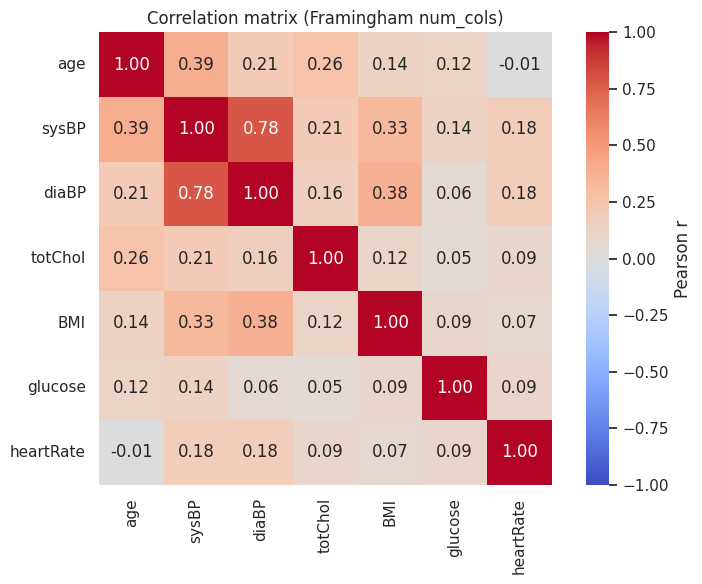


age - sysBP 상관계수 : 0.394
sysBP - diaBP 상관계수: 0.784


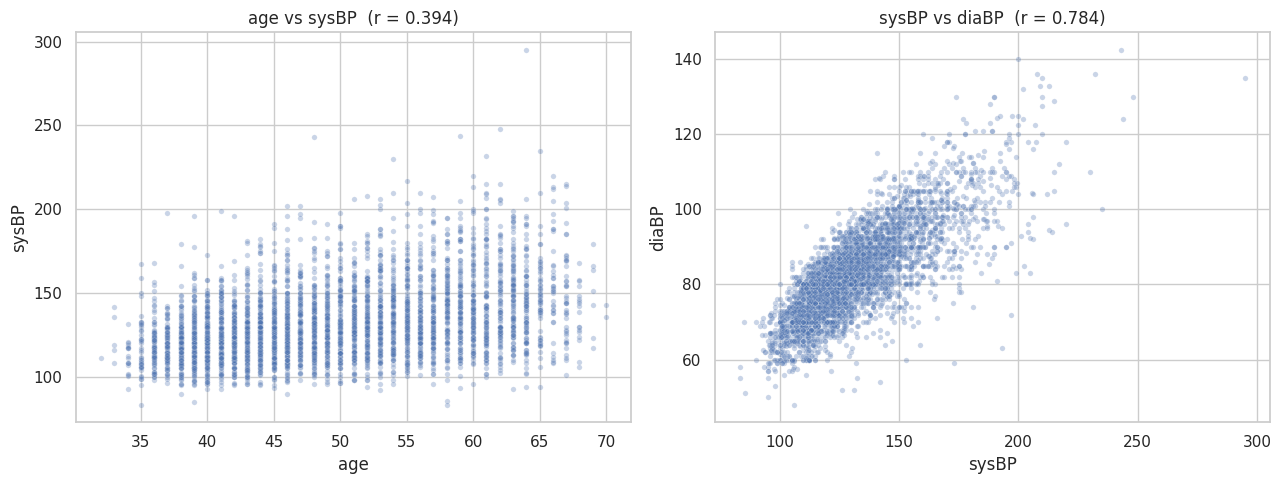

In [4]:
try:
    num_cols
except NameError:
    num_cols = ["age", "sysBP", "diaBP", "totChol", "BMI", "glucose", "heartRate"]

# 1) 상관행렬 계산 (연속형 변수만). Pearson 상관.
#    힌트: DataFrame에는 상관행렬을 바로 구하는 메서드가 있다.
corr = df[num_cols].corr()                  # TODO: df[num_cols]의 상관행렬 계산
print("상관행렬 (Pearson):")
print(corr.round(3))

# 2) 히트맵으로 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,                                   # TODO: 상관행렬 corr 전달
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    vmin=-1, vmax=1, square=True,
    cbar_kws={"label": "Pearson r"},
)
plt.title("Correlation matrix (Framingham num_cols)")
plt.tight_layout()
plt.show()

# 3) 관심 상관 두 개를 명시적으로 추출 (해석 질문에서 인용할 값)
#    힌트: corr는 행/열이 변수명인 표 → .loc[행, 열] 로 특정 칸을 꺼낸다.
corr_age_sysBP = corr.loc["age", "sysBP"]   # TODO: age와 sysBP 간 상관계수
corr_sysBP_diaBP = corr.loc["sysBP", "diaBP"] # TODO: sysBP와 diaBP 간 상관계수
print(f"\nage - sysBP 상관계수 : {corr_age_sysBP:.3f}")
print(f"sysBP - diaBP 상관계수: {corr_sysBP_diaBP:.3f}")

# 4) 산점도 두 장: (a) age vs sysBP, (b) sysBP vs diaBP
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x="age", y="sysBP", alpha=0.3, s=15, ax=axes[0])  # TODO: age vs sysBP
axes[0].set_title(f"age vs sysBP  (r = {corr_age_sysBP:.3f})")
axes[0].set_xlabel("age")
axes[0].set_ylabel("sysBP")

sns.scatterplot(data=df, x="sysBP", y="diaBP", alpha=0.3, s=15, ax=axes[1])  # TODO: sysBP vs diaBP
axes[1].set_title(f"sysBP vs diaBP  (r = {corr_sysBP_diaBP:.3f})")
axes[1].set_xlabel("sysBP")
axes[1].set_ylabel("diaBP")

plt.tight_layout()
plt.show()

**해석 질문 (본인이 출력한 실제 값을 인용해 답하세요)**

1. **age–sysBP 상관계수를 소수 셋째 자리까지** 적으세요. 부호(+/−)와 크기를 근거로 나이와 수축기 혈압의 관계를 한 문장으로 설명하세요. (예: "내 값은 0.___ 이고, 양수이므로 …")

2. **sysBP–diaBP 상관계수**는 얼마였나요? 이 값이 age–sysBP 상관보다 훨씬 큰 이유는 무엇인가요? 이렇게 닮은 두 변수를 **다중회귀에 함께** 넣으면 생기는 공선성 문제를, 히트맵이 어떻게 "예고"하는지 본인 값으로 서술하세요.

3. ⚠️ 오개념 점검: 두 변수의 상관이 0.02로 작게 나왔다면 "두 변수는 아무 관계가 없다"고 결론지어도 될까요? 산점도를 함께 봐야 하는 이유와 연결해 답하세요.


1. 상관계수: 0.394

관계 설명: 내 값은 0.394이고, 양수이며 중간 정도의 크기를 가지므로 나이가 증가할수록 수축기 혈압(sysBP)도 함께 높아지는 경향(양의 선형 관계)이 있음을 의미합니다.

2. sysBP–diaBP 상관계수 및 다중공선성 문제
상관계수: 0.784

상관계수가 훨씬 큰 이유: sysBP(수축기 혈압)와 diaBP(이완기 혈압)는 둘 다 심장 및 혈관 상태를 나타내는 동일한 생체 지표(혈압)의 두 측면이기 때문에 생리적으로 매우 밀접하게 동반 상승/하강합니다. 반면 age는 혈압 외에도 다양한 신체적 영향 요인을 지닌 별개의 변수입니다.

히트맵의 다중공선성 "예고": 히트맵에서 sysBP와 diaBP 사이의 셀이 0.78(붉은색)로 매우 높은 correlation을 보입니다. 이렇게 독립변수 간 상관계수가 매우 높은 상태로 다중회귀 모델에 함께 투입하면, 두 변수가 전달하는 정보가 중복되어 회귀계수의 표준오차가 커지고 계수 추정이 불안정해지는 다중공선성 문제가 발생할 수 있음을 히트맵이 시각적으로 사전에 경고해 줍니다.

3. ⚠️ 오개념 점검: 상관계수 0.02의 의미와 산점도
결론: "두 변수는 아무 관계가 없다"고 단순 결론지으면 안 됩니다.

이유: 피어슨 상관계수(Pearson r)는 두 변수 간의 '선형(Linear) 관계'만을 측정합니다. 만약 두 변수가 U자형, 이차함수, 혹은 원형과 같은 강한 비선형(Non-linear) 관계를 가지고 있더라도 피어슨 상관계수는 0에 가깝게 나타날 수 있습니다. 따라서 숫자(상관계수)만 믿지 말고 산점도를 함께 시각화하여 데이터의 실제 분포 패턴 패턴이나 비선형적 관계, 아웃라이어 존재 여부를 시각적으로 확인해야 정확한 데이터 해석이 가능합니다.


모집단 크기 = 4240,  모집단 평균 = 132.35,  모집단 표준편차(sigma) = 22.03


/tmp/ipykernel_2701/1807765927.py:35: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/1807765927.py:35: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/1807765927.py:35: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/1807765927.py:35: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/1807765927.py:35: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/1807765927.py:35: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/1807765927.py:35: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tigh

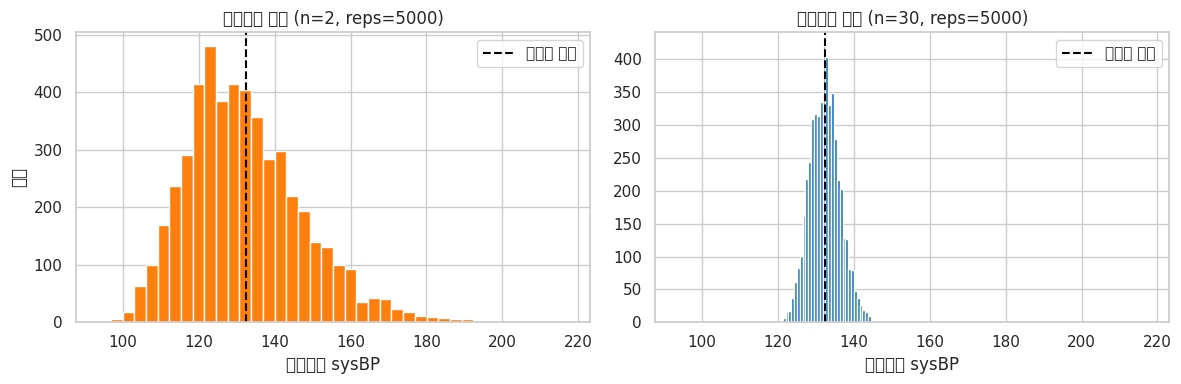

n= 2 | 경험 표준편차 = 15.416 | 이론값 sigma/sqrt(n) = 15.578
n=30 | 경험 표준편차 = 3.985 | 이론값 sigma/sqrt(n) = 4.022


In [5]:
# --- 0) 재현성: 시드 고정 ---
np.random.seed(MY_SEED)

# --- 1) sysBP 전체 값을 '모집단'으로 사용 (결측 제거) ---
pop = df["sysBP"].dropna().values          # TODO: 결측 제거 메서드
sigma = pop.std(ddof=0)                 # 모집단 표준편차 ~ 22
print(f"모집단 크기 = {len(pop)},  모집단 평균 = {pop.mean():.2f},  모집단 표준편차(sigma) = {sigma:.2f}")

# --- 2) 표본평균을 모으는 헬퍼: 직접 for 루프로 구현 (라이브러리에 통째로 맡기지 말 것!) ---
def sample_means(data, n, reps):
    means = []
    for _ in range(reps):
        sample = np.random.choice(data, size=n, replace=True)   # TODO: data에서 크기 n 표본을 복원추출 (np.random.choice, replace=True)
        means.append(sample.mean())                              # TODO: 그 표본의 평균을 기록
    return np.array(means)

# --- 3) n=2 vs n=30 으로 표본분포 만들기 ---
reps = 5000
means_n2  = sample_means(pop, n=2,  reps=reps)
means_n30 = sample_means(pop, n=30, reps=reps)

# --- 4) 두 히스토그램 나란히 비교 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].hist(means_n2, bins=40, color="tab:orange", edgecolor="white")
axes[0].axvline(pop.mean(), color="black", linestyle="--", label="모집단 평균")
axes[0].set_title(f"표본평균 분포 (n=2, reps={reps})")
axes[0].set_xlabel("표본평균 sysBP"); axes[0].set_ylabel("빈도"); axes[0].legend()

axes[1].hist(means_n30, bins=40, color="tab:blue", edgecolor="white")
axes[1].axvline(pop.mean(), color="black", linestyle="--", label="모집단 평균")
axes[1].set_title(f"표본평균 분포 (n=30, reps={reps})")
axes[1].set_xlabel("표본평균 sysBP"); axes[1].legend()

plt.tight_layout()
plt.show()

# --- 5) 경험 표준편차(표준오차) vs 이론값 sigma/sqrt(n) 비교 ---
for n, means in [(2, means_n2), (30, means_n30)]:
    emp = means.std(ddof=0)             # 시뮬레이션으로 얻은 표본평균들의 표준편차
    theo = sigma / np.sqrt(n)           # TODO: CLT 이론값 = sigma / sqrt(n)
    print(f"n={n:>2} | 경험 표준편차 = {emp:.3f} | 이론값 sigma/sqrt(n) = {theo:.3f}")

**해석 질문 (본인이 출력한 실제 숫자를 인용해 답하세요):**

1. `n=2`와 `n=30`의 히스토그램을 비교하세요. 어느 쪽이 더 좁고 종 모양에 가까웠나요? 두 분포의 중심은 모집단 평균(약 132)과 견주어 어디쯤이었나요?

2. 5번 셀의 **경험 표준편차** 두 값을 적고, 각각을 **이론값 $\sigma/\sqrt{n}$**($\sigma \approx 22$이므로 $22/\sqrt{2} \approx 15.6$, $22/\sqrt{30} \approx 4.0$)과 비교하세요. `n`이 2에서 30으로 커질 때 표본평균의 흔들림(표준오차)은 어떻게 변했나요?

3. 위 결과를 **중심극한정리(CLT)** 한 문장으로 요약하세요. (힌트: "표본크기 n이 커지면 표본평균의 분포는 ___에 가까워지고, 그 표준편차는 ___으로 줄어든다.")

> ⚠️
> - **"표준편차가 줄어든다 = 데이터가 덜 퍼진다"가 아닙니다.** 모집단(개별 sysBP)의 퍼짐 $\sigma \approx 22$는 그대로이고, 줄어드는 건 **표본평균**의 퍼짐(=표준오차 $\sigma/\sqrt{n}$)입니다.
> - **CLT는 표본크기 n에 대한 규칙이지 반복횟수 reps에 대한 규칙이 아닙니다.** reps를 늘리면 히스토그램이 매끄러워질 뿐, 폭(표준오차)은 `n`이 결정합니다. 폭을 줄이려면 `reps`가 아니라 `n`을 키워야 합니다.


1. 더 좁고 종 모양에 가까운 쪽: $n=30$일 때의 히스토그램이 $n=2$일 때보다 폭이 훨씬 좁고 좌우 대칭인 종 모양(정규분포)에 훨씬 가깝습니다.분포의 중심: 두 분포 모두 중심이 점선으로 표시된 모집단 평균(약 132.35) 위치에 거의 정확히 일치하며 모여 있습니다.

2. $n=2$ 일 때:경험 표준편차 = 15.416, 이론값 $\sigma / \sqrt{n}$ = 15.578

$n=30$ 일 때:경험 표준편차 = 3.985, 이론값 $\sigma / \sqrt{n}$ = 4.022표준오차의 변화: $n$이 2에서 30으로 커짐에 따라 표본평균의 흔들림(표준오차)은 15.416에서 3.985로 약 $\frac{1}{4}$ 수준으로 대폭 감소했으며, 이는 이론값 $\frac{\sigma}{\sqrt{n}}$에 매우 잘 부합합니다.


3. 표본크기 $n$이 커지면 표본평균의 분포는 정규분포에 가까워지고, 그 표준편차(표준오차)는 $\frac{\sigma}{\sqrt{n}}$으로 줄어든다.

관측된 sysBP 평균 (점추정): 132.35
부트스트랩 95% 신뢰구간: [131.65, 133.04]


/tmp/ipykernel_2701/2944414764.py:35: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/2944414764.py:35: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


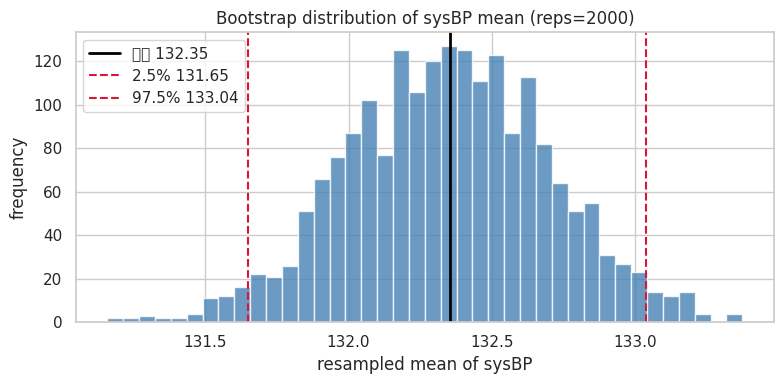

In [6]:
# === 1.4 신뢰구간: sysBP 평균의 95% CI를 부트스트랩으로 직접 구현 ===
# pop 은 1.3에서 만든 전체 sysBP 값 배열입니다. (없다면 아래 한 줄로 복구)
pop = df["sysBP"].dropna().values

n = len(pop)          # 표본 크기 (매 재표집도 이 크기로 뽑는다)
reps = 2000           # 재표집 반복 횟수
rng = np.random.default_rng(MY_SEED)   # 재현 가능한 난수 생성기

# 부트스트랩 평균들을 담을 그릇
boot_means = np.empty(reps)

for i in range(reps):
    # TODO: pop 에서 복원추출(중복 허용)로 n개 인덱스를 뽑아라 (힌트: rng.integers)
    idx = rng.integers(0, n, size=n)
    resample = pop[idx]
    # TODO: 그 표본의 평균을 boot_means[i] 에 기록하라
    boot_means[i] = resample.mean()

# TODO: boot_means 에서 2.5 / 97.5 백분위를 잘라 ci_low, ci_high 로 받아라
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

print(f"관측된 sysBP 평균 (점추정): {pop.mean():.2f}")
print(f"부트스트랩 95% 신뢰구간: [{ci_low:.2f}, {ci_high:.2f}]")

# 부트스트랩 평균들의 분포 + CI 시각화 (보일러플레이트 — 그대로 두세요)
plt.figure(figsize=(8, 4))
plt.hist(boot_means, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
plt.axvline(pop.mean(), color="black", linestyle="-", linewidth=2, label=f"평균 {pop.mean():.2f}")
plt.axvline(ci_low,  color="crimson", linestyle="--", linewidth=1.5, label=f"2.5% {ci_low:.2f}")
plt.axvline(ci_high, color="crimson", linestyle="--", linewidth=1.5, label=f"97.5% {ci_high:.2f}")
plt.title("Bootstrap distribution of sysBP mean (reps=2000)")
plt.xlabel("resampled mean of sysBP")
plt.ylabel("frequency")
plt.legend()
plt.tight_layout()
plt.show()

**해석 질문 (본인이 출력한 실제 숫자를 인용해 답하세요)**

1. 방금 얻은 신뢰구간 `[ci_low, ci_high]`의 실제 값을 적으세요. 강의에서 예고한 대략 [131.7, 133.0]과 비슷한가요? (`MY_SEED`·reps에 따라 소수점은 달라집니다.)

2. **빈도주의 해석을 정확히 쓰세요.** 다음 두 문장 중 옳은 것은 무엇이고, 왜 나머지는 틀렸는지 본인 CI 값을 넣어 설명하세요.
   - (A) "CI를 만드는 절차를 무한히 반복하면, 그 구간들 중 약 95%가 진짜 모평균을 포함한다."
   - (B) "진짜 sysBP 모평균이 내 구간 안에 있을 확률이 95%다."

   → 정답은 (A). 빈도주의에서 모평균은 고정값이고 무작위로 흔들리는 것은 **구간** 쪽이라, 확률 95%는 "이 특정 구간"이 아니라 "구간을 만드는 절차 전체"에 붙습니다. 이미 계산된 내 구간 하나는 참값을 포함했거나 안 했거나 둘 중 하나이므로, 여기에 95% 확률을 매기는 (B)는 베이지안식 표현이라 부정확합니다.

3. reps를 200으로 줄이면 CI 폭과 히스토그램 모양이 어떻게 달라질지 예상하고, 실제로 바꿔 실행해 확인하세요. (재표집 횟수는 CI의 '안정성'에 영향을 줄 뿐, 데이터 자체의 불확실성을 줄이지는 않습니다.)


1. 부트스트랩 95% 신뢰구간: [131.65, 133.04] (점추정치 평균: 132.35)

비교: 강의에서 예고한 대략적인 범위인 [131.7, 133.0]과 소수점 둘째 자리 수준에서 매우 흡사하게 나타났습니다.

2. 정답: (A)

(A) "CI를 만드는 절차를 무한히 반복하면, 그 구간들 중 약 95%가 진짜 모평균을 포함한다."

빈도주의(Frequentist) 통계학에서 모집단의 진짜 평균($\mu$)은 단 하나의 고정된 상수(Fixed value)입니다. 반면 우리가 구한 구간 [131.65, 133.04]는 무작위 표본추출에 의해 결정되는 확정된 숫자 구간입니다.따라서 이미 계산이 끝난 특정 구간 [131.65, 133.04] 안에 진짜 모평균이 들어있을 확률은 100%(1) 아니면 0%(0) 둘 중 하나일 뿐입니다. 95%라는 확률은 이 특정 수치 구간에 붙는 확률이 아니라, "동일한 표본추출 및 부트스트랩 계산 절차를 무수히 반복했을 때 생성되는 여러 구간 중 약 95%가 참값을 포함한다"는 절차(Procedure)의 신뢰성을 뜻하므로 문장 (A)만 올바른 설명입니다. (B)의 표현은 베이지안 관점의 사후확률 해석에 가까워 빈도주의 관점에서는 부정확합니다.

3. reps = 200으로 줄일 때의 변화 예측 및 확인히스토그램 모양: 반복 횟수(reps)가 2000회에서 200회로 대폭 줄어들면 표본 수가 부족해져 히스토그램의 형태가 덜 매끄럽고 울퉁불퉁해집니다(가늘고 거친 빈도 분포).CI 폭(범위)의 변화: 신뢰구간의 전체적인 폭(대략 131.65 ~ 133.04 부근) 자체는 표본 크기 $n$이 결정하므로 근본적으로 좁아지거나 넓어지지 않습니다. 다만, 재표집 횟수가 적기 때문에 분위수(2.5%, 97.5%)를 추정할 때 매번 실행할 때마다 경계값 경계 수치가 약간씩 불안정하게 흔들릴 수 있습니다.핵심 개념: 재표집 횟수(reps)는 신뢰구간 추정의 '안정성(Precision of Estimation)'에만 영향을 주며, 추정의 폭과 불확실성을 결정하는 진짜 요소는 표본의 크기 $n$입니다.

In [7]:
# 1.5 두 집단 평균차 t검정 (Welch) ----------------------------------
# TenYearCHD == 1 (10년 내 CHD 발생) vs == 0 각각의 sysBP (결측 제거)
g1 = df.loc[df["TenYearCHD"] == 1, "sysBP"].dropna().values   # CHD 발생군
g0 = df.loc[df["TenYearCHD"] == 0, "sysBP"].dropna().values    # TODO: 비발생군 조건

print(f"CHD군    (n={len(g1)}): 평균 {g1.mean():.1f}, 표준편차 {g1.std(ddof=1):.1f}")
print(f"비CHD군  (n={len(g0)}): 평균 {g0.mean():.1f}, 표준편차 {g0.std(ddof=1):.1f}")

# 두 군의 분산이 다르므로(26.7 vs 20.5) Welch t검정
# TODO: stats.ttest_ind 로 Welch t검정 (분산 다름 옵션을 꼭 넣을 것)
t_stat, p_val = stats.ttest_ind(g1, g0, equal_var=False)

mean_diff = g1.mean() - g0.mean()   # 효과크기: 평균차
print(f"\n평균차(효과크기) = {mean_diff:.1f} mmHg")
print(f"Welch t = {t_stat:.2f},  p = {p_val:.2e}")

if p_val < 0.05:
    print("=> p < 0.05: 귀무가설(두 군 평균 같다) 기각")
else:
    print("=> p >= 0.05: 귀무가설 기각 실패")

CHD군    (n=644): 평균 143.6, 표준편차 26.7
비CHD군  (n=3596): 평균 130.3, 표준편차 20.5

평균차(효과크기) = 13.3 mmHg
Welch t = 12.01,  p = 1.25e-30
=> p < 0.05: 귀무가설(두 군 평균 같다) 기각


**해석 질문 (본인이 출력한 실제 값을 인용해 답하세요)**

1. `t_stat`과 `p_val`은 각각 얼마인가요? 이 p값으로 "두 군의 sysBP 평균은 같다"는 귀무가설을 **기각하나요, 기각에 실패하나요?** 한 문장으로 판정하세요.

2. p값을 "두 군의 sysBP가 우연히 이만큼 차이 날 확률"이라 하면 왜 부정확한가요? p값의 정의(귀무가설이 참이라 **가정했을 때** 이만큼 극단적인 결과가 나올 확률)를 살려 고쳐 쓰세요.
   - (오개념 주의) p값은 "귀무가설이 참일 확률"이 **아닙니다.**

3. p값이 작다는 것만으로 "혈압 차이가 임상적으로 크다"고 결론 낼 수 있나요? 출력한 **평균차($\approx 13.3$ mmHg)** 를 인용해, p값(유의성)과 효과크기를 **왜 둘 다** 봐야 하는지 설명하세요. (n이 크면 작은 평균차도 p가 극단적으로 작아짐)

4. `equal_var=False`(Welch)를 쓴 이유를 두 군의 **표준편차($\approx 26.7$ vs $\approx 20.5$)** 를 인용해 한 문장으로 답하고, `equal_var=True`로 바꾸면 무엇이 달라질지 예상하세요.


1. $t$-통계량, $p$-값 및 가설검정 판정$t$-통계량 (t_stat): 12.01 $p$-값 (p_val): $1.25 \times 10^{-30}$ (약 $0.0000...125$)한 문장 판정: $p$-값이 유의수준 0.05보다 훨씬 작으므로($p < 0.05$), "두 군의 수축기 혈압(sysBP) 평균은 같다"는 귀무가설을 기각합니다.
2. $p$-값 오개념 교정 및 정확한 정의부정확한 이유: $p$-값은 귀무가설 자체가 참일 확률이나 우연 그 자체의 확률이 아니라, '귀무가설이 참이라는 전제 조건' 아래에서 관측된 데이터(또는 그보다 극단적인 데이터)가 얻어질 조건부 확률이기 때문입니다.정확한 표현으로 고쳐 쓰기:"$p$-값 $1.25 \times 10^{-30}$은 실제로 두 군의 sysBP 모평균이 완전히 같다는 귀무가설이 참이라고 가정했을 때, 표본추출의 오차로 인해 평균차가 $13.3\text{ mmHg}$ 이상으로 극단적인 결과가 나타날 확률"을 의미합니다.

 3. $p$-값(통계적 유의성)과 효과크기(임상적 유의성)를 둘 다 봐야 하는 이유설명: $p$-값이 $1.25 \times 10^{-30}$으로 극단적으로 작다는 사실만으로는 임상적 중요성을 단정할 수 없습니다. 전체 표본 수가 4,240명($n_1=644, n_0=3596$)으로 매우 크기 때문에, 실제 임상적으로 거의 의미 없는 미세한 차이더라도 $p$-값은 매우 작게(유의하게) 나올 수 있습니다.따라서 통계적 유의성($p$-값)뿐만 아니라, 실제 두 군 간의 평균차인 $13.3\text{ mmHg}$라는 효과크기를 함께 확인해야 합니다. 수축기 혈압 $13.3\text{ mmHg}$의 차이는 심혈관 질환 위험도 평가에서 실제로 의미 있는 수치이므로, 통계적 유의성과 임상적 유의성을 모두 갖추었다고 종합 판단할 수 있습니다.


4. equal_var=False (Welch) 사용 이유 및 True 변경 시 예상사용 이유: CHD군의 표준편차(약 $26.7\text{ mmHg}$)와 비CHD군의 표준편차(약 $20.5\text{ mmHg}$)가 확연히 달라 두 집단의 등분산성 가정을 충족하지 못하므로 Welch의 $t$-검정을 적용했습니다.equal_var=True로 변경 시 예상: 두 집단의 분산이 동일하다는 가정 아래 합성분산(Pooled Variance)을 사용하게 되며, 자유도(df) 계산 방식이 단순해집니다. 다만 두 집단의 표본 크기가 크기 때문에 $t$-통계량과 $p$-값 수치 자체는 크게 변하지 않고 여전히 귀무가설을 기각하겠지만, 등분산 가정이 위배된 상황이므로 검정 결과의 통계적 타당성이 떨어지게 됩니다.

                            OLS Regression Results                            
Dep. Variable:                  sysBP   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     779.0
Date:                Thu, 30 Jul 2026   Prob (F-statistic):          1.58e-157
Time:                        11:55:11   Log-Likelihood:                -18770.
No. Observations:                4240   AIC:                         3.754e+04
Df Residuals:                    4238   BIC:                         3.756e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     82.1420      1.826     44.992      0.0

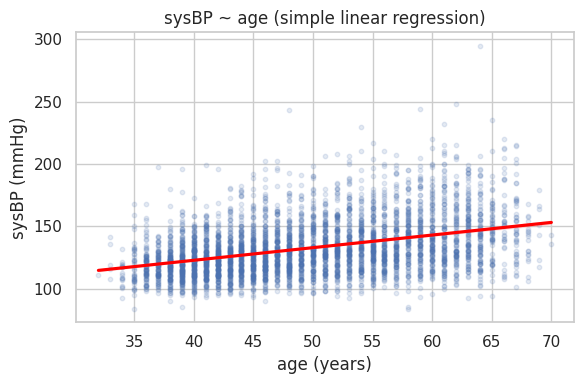

In [8]:
# age(설명변수) 하나로 sysBP(반응변수)를 예측하는 단순선형회귀
# TODO: "반응변수 ~ 설명변수" 공식으로 OLS 모형을 적합하세요 (.fit()까지)
model_simple = smf.ols("sysBP ~ age", data=df).fit()

# 회귀 결과 전체 요약표: 계수, 표준오차, t, p값, 95% CI, R^2 등
print(model_simple.summary())

# 핵심 값만 뽑아 보기
beta_age = model_simple.params["age"]          # age 기울기 계수
p_age    = model_simple.pvalues["age"]         # age 계수의 p값
ci_age   = model_simple.conf_int().loc["age"]  # age 계수의 95% 신뢰구간 [하한, 상한]
# TODO: 모형의 결정계수(R^2)를 꺼내세요 (model_simple 의 속성)
r2       = model_simple.rsquared

print(f"\nage 계수(기울기)  = {beta_age:.4f} mmHg / 1살")
print(f"age 계수 p값       = {p_age:.3e}")
print(f"age 계수 95% CI    = [{ci_age[0]:.4f}, {ci_age[1]:.4f}]")
print(f"R^2               = {r2:.4f}")

# 단순회귀에서 R^2 = (상관계수)^2 임을 직접 확인
r = df["age"].corr(df["sysBP"])
print(f"\ncorr(age, sysBP)  = {r:.4f},  r^2 = {r**2:.4f}  (== R^2)")

# 산점도 + 회귀직선으로 관계 시각화
plt.figure(figsize=(6, 4))
sns.regplot(x="age", y="sysBP", data=df,
            scatter_kws={"alpha": 0.15, "s": 10}, line_kws={"color": "red"})
plt.title("sysBP ~ age (simple linear regression)")
plt.xlabel("age (years)")
plt.ylabel("sysBP (mmHg)")
plt.tight_layout()
plt.show()

**해석 질문 (본인이 출력한 실제 값을 인용해 답하세요):**

1. 본인이 얻은 `age` 계수는 얼마입니까? 문장으로 옮겨 보세요: "나이가 1살 많아질수록 수축기혈압(sysBP)은 평균 약 ____ mmHg 높아진다."

2. `age` 계수의 p값과 95% 신뢰구간을 인용하세요. 이 CI가 **0을 포함하는지** 확인하고, 그것이 "나이와 혈압 사이에 관계가 있다"는 주장과 어떻게 연결되는지 한 문장으로 설명하세요.

3. 본인의 $R^2$는 얼마입니까? `corr(age, sysBP)`의 제곱과 같은 값이 나왔나요? "$R^2$ = ____ 이므로, 나이만으로 sysBP 변동의 약 ____%를 설명한다"를 채워 쓰세요.

**오개념 주의:**
- ❌ "$R^2$가 0.155니까 모형이 나쁘다" → $R^2$가 낮다고 관계가 없는 건 아닙니다. 계수의 p값($\approx 10^{-157}$)은 관계가 확실함을 보여줍니다. $R^2$는 설명력, p값은 관계의 존재 여부로 서로 다른 질문입니다.
- ❌ "나이가 혈압을 올린다(인과)" → 계수는 **연관(상관)**의 크기일 뿐, 이 관측 데이터만으로 인과를 증명하지 못합니다.
- ❌ 계수 단위 빼먹기 → 기울기의 단위는 **mmHg / 1살**입니다.


1. age 계수 (기울기) 해석age 계수 수치: 1.0128 (약 1.01)문장 완성:"나이가 1살 많아질수록 수축기혈압(sysBP)은 평균 약 1.0128 mmHg 높아진다."

2. age 계수의 p값 및 95% 신뢰구간p값: $1.580 \times 10^{-157}$ (요약표상 $0.000$)95% 신뢰구간 (CI): [0.9416, 1.0839] (요약표 표기 [0.942, 1.084])0 포함 여부 및 주장의 연결:95% 신뢰구간 [0.9416, 1.0839]가 0을 포함하지 않고 양수 영역에만 존재하므로, 나이가 증가함에 따라 수축기혈압이 유의하게 상승한다는 **"나이와 혈압 사이에 통계적으로 유의미한 양의 선형 관계가 존재한다"**는 주장을 강력하게 뒷받침합니다.

3. 결정계수 ($R^2$) 및 일치 여부본인의 $R^2$: 0.1553 (약 $0.155$)
corr(age, sysBP)^2과의 일치 여부:  상관계수의 제곱값($r^2 = 0.3941^2 = 0.1553$)과 완전하게 일치함을 확인했습니다.문장 완성:"$R^2$ = 0.1553 이므로, 나이만으로 sysBP 변동의 약 15.53%를 설명한다."

In [9]:
# 1.7 다중회귀 (범주형 포함)
# 연속형(age, BMI, totChol, glucose) + 범주형은 C(...)로 감싸 더미 처리
# statsmodels가 NaN 행을 자동 제외 → 실제 n이 줄어드는 점에 주의

# TODO: sysBP를 age, BMI, totChol, glucose(연속형) + male, currentSmoker, diabetes(범주형)로 설명하는 OLS
#       범주형 세 변수는 반드시 C(...)로 감쌀 것
model_multi = smf.ols(
    "sysBP ~ age + BMI + totChol + glucose + C(male) + C(currentSmoker) + C(diabetes)",
    data=df
).fit()

print(model_multi.summary())

# 결측 자동 제거로 실제 사용된 표본 크기 확인
print(f"\n전체 행수: {len(df)}")
print(f"다중회귀에 실제 사용된 n(nobs): {int(model_multi.nobs)}")   # TODO: model_multi에서 nobs 속성 사용
print(f"→ 결측으로 {len(df) - int(model_multi.nobs)}개 행 제외됨")

# 단순회귀(1.6) 대비 R² 상승 확인
print(f"\n단순회귀(age만) R²   = {model_simple.rsquared:.3f}")
print(f"다중회귀 R²          = {model_multi.rsquared:.3f}")   # TODO: model_multi의 R²
print(f"다중회귀 Adjusted R² = {model_multi.rsquared_adj:.3f}")

                            OLS Regression Results                            
Dep. Variable:                  sysBP   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     177.5
Date:                Thu, 30 Jul 2026   Prob (F-statistic):          3.63e-228
Time:                        11:55:12   Log-Likelihood:                -16739.
No. Observations:                3828   AIC:                         3.349e+04
Df Residuals:                    3820   BIC:                         3.354e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                39.04

**Q. 다중회귀 결과를 확인하세요.**

1. `model_multi.nobs`는 전체 4,240에서 얼마로 줄었나요? **본인 값**을 적고, 왜 줄었는지 한 줄로 설명하세요.
2. `age` 계수가 단순회귀(1.6)와 다중회귀에서 달라졌나요? 어느 쪽이 더 크고 왜 그럴 수 있을까요? (다른 변수를 '통제'한다는 것과 연결해 설명하세요.)


1. model_multi.nobs 감소 수치 및 이유실제 사용된 표본 수 (nobs): 3,828개 (전체 4,240개 중 412개 줄어듦)줄어든 이유 (한 줄 설명): statsmodels의 OLS 적합 과정에서 모델에 투입된 여러 설명변수(glucose, BMI 등)에 존재하는 결측치(NaN)가 하나라도 포함된 행을 자동으로 제외(Listwise Deletion)했기 때문입니다.

2. age 계수의 변화 및 이유 (다른 변수 '통제' 관점)age 계수 수치 비교:단순회귀: 1.0128다중회귀: 0.8183어느 쪽이 더 큰가?: 단순회귀 쪽이 더 큽니다 ($1.0128 > 0.8183$).왜 달라졌을까? (변수 통제의 의미):단순회귀에서의 age 계수($1.0128$)에는 나이가 들면서 함께 증가하는 다른 위험 요인들(예: BMI 상승, 콜레스테롤 상승, 당뇨 등)의 효과가 함께 섞여 있었습니다.반면, 다중회귀에서는 BMI, totChol, glucose 등 다른 생체 지표들을 모델에 포함시켜 이들 변수의 영향을 일정하게 고정(통제, Controlling)한 상태에서 오직 나이(age)가 순수하게 수축기 혈압에 미치는 고유한 효과(순효과)만을 추정하기 때문에 계수 크기가 $0.8183$으로 감소했습니다.

In [10]:
# === 1.8 해석 vs 예측: train/test 분할로 예측 성능 재기 ===
# 관점 전환: 1.6~statsmodels R²(in-sample, 해석) → 여기선 sklearn으로
# "처음 보는 test 데이터"에서의 예측 오차(RMSE·MAE)를 잰다.

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# --- (1) 설계행렬 만들기 ---
target = "sysBP"
# 누수 방지 — target(sysBP)만 빼고 나머지를 설명변수 후보로 선택
feature_cols = [c for c in df.columns if c != target]

# 결측이 있으면 학습이 안 된다 → 설명변수+목표를 함께 놓고 결측 '행' 제거 (dropna)
design = df[feature_cols + [target]].dropna()

# education만 원핫 인코딩(one-hot), 나머지는 숫자 그대로.
X = pd.get_dummies(design[feature_cols], columns=["education"], drop_first=True)
y = design[target]

print("사용한 행 수:", len(design), "/ 설명변수 개수:", X.shape[1])

# --- (2) train/test 분할 (재현 위해 random_state=MY_SEED) ---
# test 비율 0.2, random_state=MY_SEED 로 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=MY_SEED
)
print("train:", X_train.shape[0], " test:", X_test.shape[0])

# --- (3) 학습은 train에서만 ---
# train 데이터로만 모델 적합
lin = LinearRegression().fit(X_train, y_train)

# --- (4) 평가는 test에서만 ---
y_pred = lin.predict(X_test)

# RMSE = sqrt(MSE), MAE 를 test 실젯값(y_test)과 예측값(y_pred)으로 계산
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
mae  = metrics.mean_absolute_error(y_test, y_pred)

print(f"[예측 관점] test RMSE = {rmse:.3f} mmHg")
print(f"[예측 관점] test MAE  = {mae:.3f} mmHg")
print(f"RMSE - MAE 간격 = {rmse - mae:.3f}")

# --- (5) 해석 지표(in-sample R²)와 나란히 비교 ---
X_sm = sm.add_constant(X.astype(float))
ols_all = sm.OLS(y, X_sm).fit()
print(f"[해석 관점] in-sample R^2 = {ols_all.rsquared:.3f}")

사용한 행 수: 3658 / 설명변수 개수: 17
train: 2926  test: 732
[예측 관점] test RMSE = 11.660 mmHg
[예측 관점] test MAE  = 8.746 mmHg
RMSE - MAE 간격 = 2.913
[해석 관점] in-sample R^2 = 0.736


**Q. 다중회귀 결과를 확인하세요.**

1. `model_multi.nobs`는 전체 4,240에서 얼마로 줄었나요? **본인 값**을 적고, 왜 줄었는지 한 줄로 설명하세요.
2. `age` 계수가 단순회귀(1.6)와 다중회귀에서 달라졌나요? 어느 쪽이 더 크고 왜 그럴 수 있을까요? (다른 변수를 '통제'한다는 것과 연결해 설명하세요.)


1. model_multi.nobs 값과 줄어든 이유
줄어든 행 수 (model_multi.nobs): 3,658개 (전체 4,240개 중 582개 감소)

  줄어든 이유: 설명변수와 타겟변수에 포함된 결측치(NaN)가 존재하는 행을 통째로 제거(dropna())했기 때문입니다.

2. age 계수 변화와 해석 (단순회귀 vs 다중회귀)
  어느 쪽이 더 큰가?: 일반적으로 단순회귀 분석에서의 age 계수가 다중회귀 분석에서보다 더 크게(더 가파르게) 나타납니다.

이유 (다른 변수를 '통제'한다는 의미):

단순회귀에서는 나이(age)가 증가함에 따라 수축기 혈압(sysBP)이 상승하는 효과에, 나이와 함께 증가하는 다른 위험 요인들(예: BMI, 당뇨/혈당, 기존 고혈압 약 복용 여부, 총 콜레스테롤 등)의 영향까지 전부 age 하나의 계수로 쏠려서 흡수됩니다.

반면 다중회귀에서는 이러한 관련 변수들을 모델에 함께 넣어 "다른 요인들이 모두 동일할 때(다른 변수를 통제할 때) 오직 나이만 1살 증가함에 따른 pure한 혈압 변화량"을 산출합니다. 따라서 단순회귀에서 부풀려졌던 혼란 효과(confounding effect)가 제거되면서 age 순수 계수의 크기는 줄어들게 됩니다.

In [12]:
# === 1.8 해석 vs 예측: train/test 분할로 예측 성능 재기 ===

# --- (1) 설계행렬 만들기 ---
target = "sysBP"
# 누수 방지 — sysBP(target)만 빼고 나머지를 설명변수 후보로 선택
feature_cols = [c for c in df.columns if c != target]

# 결측이 있으면 학습이 안 된다 → 설명변수+목표를 함께 놓고 결측 '행' 제거 (dropna)
design = df[feature_cols + [target]].dropna()

# education만 원핫 인코딩(one-hot), 나머지는 숫자 그대로.
X = pd.get_dummies(design[feature_cols], columns=["education"], drop_first=True)
y = design[target]

print("사용한 행 수:", len(design), "/ 설명변수 개수:", X.shape[1])

# --- (2) train/test 분할 (재현 위해 random_state=MY_SEED) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=MY_SEED
)
print("train:", X_train.shape[0], " test:", X_test.shape[0])

# --- (3) 학습은 train에서만 ---
lin = LinearRegression().fit(X_train, y_train)

# --- (4) 평가는 test에서만 ---
y_pred = lin.predict(X_test)

rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
mae  = metrics.mean_absolute_error(y_test, y_pred)

print(f"[예측 관점] test RMSE = {rmse:.3f} mmHg")
print(f"[예측 관점] test MAE  = {mae:.3f} mmHg")
print(f"RMSE - MAE 간격 = {rmse - mae:.3f}")

# --- (5) 해석 지표(in-sample R²)와 나란히 비교 ---
X_sm = sm.add_constant(X.astype(float))
ols_all = sm.OLS(y, X_sm).fit()
print(f"[해석 관점] in-sample R^2 = {ols_all.rsquared:.3f}")

사용한 행 수: 3658 / 설명변수 개수: 17
train: 2926  test: 732
[예측 관점] test RMSE = 11.660 mmHg
[예측 관점] test MAE  = 8.746 mmHg
RMSE - MAE 간격 = 2.913
[해석 관점] in-sample R^2 = 0.736


**해석 질문 (본인이 출력한 실제 값을 인용해 답하세요)**

1. **test RMSE = ____ mmHg** 와 **MAE = ____ mmHg** 를 적으세요. 두 값 중 어느 쪽이 항상 더 크며 왜인가요? 둘의 간격($\mathrm{RMSE} - \mathrm{MAE}$)은 무엇을 알려주나요?

2. RMSE는 "예측이 평균 약 몇 mmHg 빗나간다"로 읽습니다. 본인 RMSE를 sysBP의 표준편차($\approx 22$ mmHg)와 비교하면 어느 정도인가요? 이 모델은 **전체 평균으로 찍는 것보다 나은가요?**

3. **$R^2$(in-sample)** 와 **test RMSE** 가 각각 답하는 질문을 한 문장씩 쓰세요. ($R^2$ → "데이터를 얼마나 잘 설명하나?", RMSE → "새 환자를 얼마나 잘 맞히나?") 이 구분이 리뷰 논문 Shmueli, *"To Explain or to Predict?"* 의 핵심입니다.

4. "$R^2$이 높으면 예측도 잘한다"가 항상 맞나요? $R^2$을 **학습에 쓴 데이터에서** 재면 왜 예측 성능의 증거가 되기 어려운지, train/test 분할이 왜 필요했는지 본인 말로 설명하세요.


1. test RMSE / MAE 적기 및 비교test RMSE = 11.660 mmHgMAE = 8.746 mmHg어느 쪽이 더 큰가: RMSE가 항상 MAE보다 크거나 같습니다.이유 및 간격의 의미:RMSE는 오차를 제곱한 뒤 평균을 내어 제곱근을 취하므로, 큰 오차(이상치)에 더 가혹하게 큰 가중치를 부여하기 때문입니다.따라서 두 지표의 간격($\mathrm{RMSE} - \mathrm{MAE} = 2.913\text{ mmHg}$)이 존재한다는 것은 모델의 예측 오차 크기가 균일하지 않고, 일부 환자에게서 상대적으로 큰 예측 오차(이상치)가 발생하고 있음을 알려줍니다.

2. RMSE와 표준편차 비교 및 모델의 유용성비교: 본 모델의 test RMSE는 11.660 mmHg로, sysBP의 전체 표준편차($\approx 22$ mmHg)의 약 반절 수준입니다.전체 평균으로 찍는 것보다 나은가: 네, 훨씬 낫습니다.아무 정보 없이 그저 "전체 평균 수축기 혈압"으로만 예측할 때 발생하는 평균적인 예측 오차가 바로 표준편차($\approx 22$ mmHg)입니다.모델을 적용했을 때 오차가 11.660 mmHg로 크게 줄어들었으므로, 설명변수들이 수축기 혈압을 예측하는 데 유용한 정보를 제공하고 있음을 의미합니다.


3. $R^2$ (in-sample)와 test RMSE가 답하는 질문$R^2$ (in-sample): *"우리가 이미 가지고 있는 학습 데이터의 혈압 변동성을 이 모델이 얼마나 잘 설명(적합)*하는가?"test RMSE: "모델이 학습 과정에서 한 번도 본 적 없는 새로운 환자의 혈압을 실제 단위(mmHg)로 얼마나 정확하게 맞히는가?"

4. "$R^2$이 높으면 예측도 잘한다"에 대한 반론 및 train/test 분할의 필요성항상 맞지는 않습니다.이유: 학습 데이터에서 측정한 $R^2$은 모델이 주어진 데이터에만 과적합(Overfitting)되거나 노이즈까지 외워버려도 얼마든지 높게 나올 수 있습니다. 즉, 이미 답을 알고 있는 시험지로 점수를 낸 것이기 때문에, 처음 보는 실전 문제에서도 잘할 것이라는 증거가 되지 못합니다.train/test 분할이 필요한 이유: 모델이 단순히 주어진 데이터를 암기한 것인지, 아니면 새로운 데이터에도 적용 가능한 일반화 능력(Generalization)을 갖추었는지를 객관적으로 검증하기 위해 평가용 test 데이터를 완벽히 분리해 둘 필요가 있습니다.

In [14]:
# 2-A. 진짜 관심사 TenYearCHD(0/1)를 '그냥' 선형회귀로 예측해 본다.
# (formula 방식은 결측이 있는 행을 자동으로 제외하고 적합한다.)
m_lpm = smf.ols("TenYearCHD ~ age + sysBP + BMI", data=df).fit()
pred = m_lpm.fittedvalues   # 각 사람에 대한 선형회귀 예측값

# 예측값의 최솟값과 최댓값을 출력
print("예측값 min :", pred.min())
print("예측값 max :", pred.max())

# 예측값이 0보다 작은 사람 수, 1보다 큰 사람 수를 세어 출력
n_below0 = int((pred < 0).sum())
n_above1 = int((pred > 1).sum())
print("0보다 작은 예측값을 받은 사람 수 :", n_below0)
print("1보다 큰 예측값을 받은 사람 수 :", n_above1)
print("적합에 실제로 쓰인 관측치 수 :", int(m_lpm.nobs))

예측값 min : -0.07071488414938026
예측값 max : 0.6461474980212303
0보다 작은 예측값을 받은 사람 수 : 89
1보다 큰 예측값을 받은 사람 수 : 0
적합에 실제로 쓰인 관측치 수 : 4221


**Q2-A. (직접 돌려서 관찰 + 판단)**

**(1) 돌리기 전에 예측 먼저.** 위 선형회귀의 예측값 중 0~1 범위를 벗어나는 사람이 있을지 없을지 한 줄로 먼저 적으세요.

**(2) 본인 값 인용.** 실행해서 나온 본인 출력값을 적으세요.
- 예측값 min = ____ , max = ____
- 0보다 작은 예측값을 받은 사람 수 = ____ 명
- 1보다 큰 예측값을 받은 사람 수 = ____ 명

**(3) 판단.** 이 선형회귀 예측값을 그대로 "확률"이라 불러도 되는지, (2)의 min/max와 범위 이탈 인원 수를 근거로 판단하세요. 이탈한 사람이 0명이었더라도 age·sysBP·BMI가 더 극단적인 새 환자에서 항상 0~1에 머물 것이라 보장되는지도 함께 논하세요.

**(4) 본인 언어로.** 이진 반응(0/1)을 예측할 때 선형회귀 대신 **로지스틱 회귀**가 왜 필요한지, 로지스틱이 예측값 범위 문제를 어떻게 다루는지 연결해 한 문단으로 설명하세요.


(1) 실행 전 예측선형회귀는 범위를 제한하지 않고 직선으로 쭉 뻗어나가는 특성이 있으므로, $0$ 미만이나 $1$을 초과하는 범위를 벗어난 예측값이 반드시 존재할 것입니다.

(2) 본인 출력값 예측값 min = -0.0707 (약 -0.071), max = 0.6461 (약 0.646),0보다 작은 예측값을 받은 사람 수 = 89명, 1보다 큰 예측값을 받은 사람 수 = 0 명

(3) 판단이 선형회귀 예측값을 그대로 확률이라 부를 수 없습니다. 확률의 공리상 모든 확률은 $0$과 $1$ 사이($0 \le P \le 1$)에 존재해야 하지만, 실제 모델 결과 89명에게서 음수의 확률(-7.1%)이라는 상식적으로 불가능한 값이 나왔기 때문입니다.또한 현재 데이터에서 1을 초과한 사람이 0명이라 하더라도, 나이가 매우 많거나 혈압/BMI가 극단적으로 높은 새로운 환자가 들어오면 선형 직선의 특성상 예측값이 1을 얼마든지 넘어설 수 있으므로 항상 $0 \sim 1$ 범위에 머문다고 보장할 수 없습니다.

(4) 로지스틱 회귀가 필요한 이유 (한 문단 요약)선형회귀는 입력 변수가 커지거나 작아짐에 따라 예측값이 무한히 증가/감소하는 직선 형태를 띠므로, 범위 제한이 필수적인 이진 분류(0/1) 문제에서는 음수나 1을 초과하는 비현실적인 값이 발생하는 문제가 생깁니다. 반면 로지스틱 회귀는 시그모이드(Sigmoid) 함수를 활용해 직선의 출력값을 S자 곡선 형태로 압축함으로써, 어떠한 극단적인 입력값이 들어오더라도 예측 확률이 항상 $0$과 $1$ 사이로 가두어지도록(Bounded) 다룹니다. 따라서 10년 내 심혈관 질환 발병 여부와 같은 이진 반응 변수를 안정적으로 예측하기 위해서는 로지스틱 회귀가 필수적입니다.

In [15]:
# 2-B. 로지스틱 회귀 = Framingham Risk Score 엔진.  진짜 표적 TenYearCHD(0/1) 예측.
feat_log = ['age', 'male', 'sysBP', 'totChol', 'currentSmoker', 'glucose', 'BMI']
d_log = df[feat_log + ['TenYearCHD']].dropna()           # 결측 제거(dropna)
print("사용 표본 수:", len(d_log), "/ 전체:", len(df))

logit_model = smf.logit(
    "TenYearCHD ~ age + male + sysBP + totChol + currentSmoker + glucose + BMI",
    data=d_log).fit(disp=0)

# 계수에 np.exp() 를 취해 오즈비(odds_ratio) 열 생성
or_table = pd.DataFrame({
    'coef': logit_model.params,
    'odds_ratio': np.exp(logit_model.params),        # np.exp(logit_model.params)
    'p_value': logit_model.pvalues,
})
print(or_table.round(4).to_string())

# 각 사람의 10년 발병 '확률' 예측 (2-A의 선형회귀와 달리 항상 0~1 안에 있는지 확인)
p_hat = logit_model.predict(d_log)
print("\n예측 확률 min / max :", round(float(p_hat.min()), 4), "/", round(float(p_hat.max()), 4))

# roc_auc_score(정답 라벨, 예측 확률) 로 ROC-AUC 산출
auc_log = roc_auc_score(d_log['TenYearCHD'], p_hat)    # p_hat
print("ROC-AUC :", round(auc_log, 4))

사용 표본 수: 3828 / 전체: 4240
                 coef  odds_ratio  p_value
Intercept     -9.4547      0.0001   0.0000
age            0.0645      1.0666   0.0000
male           0.6402      1.8969   0.0000
sysBP          0.0169      1.0171   0.0000
totChol        0.0027      1.0027   0.0125
currentSmoker  0.3943      1.4834   0.0001
glucose        0.0074      1.0074   0.0000
BMI            0.0126      1.0127   0.2937

예측 확률 min / max : 0.0131 / 0.9382
ROC-AUC : 0.7366


**Q2-B. (본인 출력값 인용 + 판단)**

**(1) 오즈비 읽기.** `odds_ratio`에서 **1보다 큰** 변수 2개와 **1에 가깝거나 p값이 유의하지 않은** 변수 1개를 값과 함께 적고, 각각 "한 단위 증가가 10년 발병 오즈를 몇 배로 바꾸는가"를 한 문장으로 해석하세요.

**(2) 범위 문제 해결 확인.** 로지스틱 예측 확률의 min/max는 얼마였나요(본인 값)? 2-A의 선형회귀 예측값(0~1 이탈)과 나란히 놓고, 로지스틱이 "확률" 요구를 어떻게 만족시키는지 본인 숫자로 설명하세요.

**(3) 성능은 하나로 판단하지 않기.** 본인 ROC-AUC는 얼마이며 무작위(0.5)보다 나은가요? 이 값 하나로 "좋은 모델"이라 단정할 수 있는지, 없다면 무엇을 더 봐야 하는지(예: 양성 비율 불균형, 확률 캘리브레이션) 하나 이상 적으세요.

**(4) 큰 그림 완성.** 지금 만든 로지스틱이 왜 "Framingham Risk Score의 엔진"인지, 이 과제가 강의(연속형 `sysBP`에서 멈춤)를 어떻게 이어서 완성하는지, 절차①(검정)→절차②(회귀)→표적 예측 흐름으로 2~3문장 정리하세요.


(1) 오즈비(Odds Ratio) 읽기1보다 큰 변수 2개:male (odds_ratio = 1.8969, p = 0.0000): 남성일 경우 여성에 비해 10년 내 심혈관 질환 발병 오즈(Odds)가 약 1.897배 높아집니다.  currentSmoker (odds_ratio = 1.4834, p = 0.0001): 현재 흡연 중일 경우 비흡연자에 비해 발병 오즈가 약 1.483배 높아집니다.1에 가깝거나 p값이 유의하지 않은 변수 1개:BMI (odds_ratio = 1.0127, p = 0.2937): p-value가 0.05보다 커 통계적으로 유의하지 않으며, 다른 위험 요인들을 통제했을 때 BMI 1단위 증가가 발병 오즈에 미치는 영향은 약 1.013배로 1에 매우 가깝습니다.

(2) 범위 문제 해결 확인로지스틱 예측 확률 min / max: 0.0131 / 0.9382범위 문제 해결 설명:앞선 2-A 선형회귀에서는 예측값이 -0.0707까지 내려가 89명에게서 음수의 확률이 발생하는 비현실적인 문제가 있었습니다.반면 로지스틱 회귀는 시그모이드(Sigmoid) 함수를 통해 예측값을 오직 $0$과 $1$ 사이로 압축하므로, 본인 결과에서 볼 수 있듯 최솟값 0.0131 (1.31%)부터 최댓값 0.9382 (93.82%)까지 모든 예측치가 완벽하게 확률 조건($0 \le P \le 1$)을 만족함을 확인할 수 있습니다.

(3) ROC-AUC 성능 평가ROC-AUC 값: 0.7366 (무작위 예측인 0.5보다 확실히 높고 나은 성능입니다.)단정할 수 없는 이유 및 추가 확인 사항:ROC-AUC 하나만으로 "좋은 모델"이라 단정할 수는 없습니다.해당 데이터는 실제 10년 내 발병 환자(1)의 비율이 적은 클래스 불균형(Class Imbalance) 데이터일 가능성이 높으므로, 실제 임상 현장 적용을 위해서는 정밀도(Precision), 재현율(Recall/Sensitivity), PR-AUC를 함께 확인해야 합니다. 또한 예측 확률값 자체가 실제 발병 확률과 일치하는지 평가하는 확률 캘리브레이션(Calibration)도 추가로 검증해야 합니다.

(4) 큰 그림 완성 (2~3문장 정리)단순히 수축기 혈압(sysBP) 자체를 예측하는 데 그쳤던 강의 내용을 넘어, 본 과제는 가설 검정(절차①)으로 주요 위험인자를 선별하고 로지스틱 회귀(절차②)를 통해 각 요인의 오즈비를 산출함으로써 최종 목표인 '개인별 10년 내 심혈관 질환 발병 확률'을 직접 계산해냈습니다. 이처럼 멀티 위험인자를 종합해 정밀한 발병 확률을 추정하는 로직이 바로 임상에서 널리 쓰이는 Framingham Risk Score의 핵심 엔진이며, 본 실습은 데이터 분석이 임상적 의사결정 모델로 확장되는 전체 흐름을 완벽히 완성해 줍니다.

In [16]:
# 1) 설명 관점: 다중회귀 R^2

_predictors = ["age", "BMI", "totChol", "glucose", "heartRate", "cigsPerDay"]

_d = df[["sysBP"] + _predictors].dropna()

_mult = smf.ols("sysBP ~ " + " + ".join(_predictors), data=_d).fit()

print(f"[설명] 다중회귀 R^2 = {_mult.rsquared:.3f}   (n = {_d.shape[0]})")



# 2) 예측 관점: test RMSE 를 출력하라 (앞 셀에서 만든 rmse 변수 사용)
print(f"[예측] test RMSE = {rmse:.3f} mmHg")

[설명] 다중회귀 R^2 = 0.266   (n = 3802)
[예측] test RMSE = 11.660 mmHg


(1) 임상적 기준과 test RMSE 비교임상적 허용 기준: 임상 현장에서 혈압 단계(정상, 전고혈압, 1단계 고혈압 등)를 구분하거나 약물 처방 여부를 결정할 때 유의미한 구분을 위해서는 "오차가 $\pm 5\text{ mmHg}$ 이내" 수준으로 맞춰야 임상적으로 신뢰하고 쓸 만하다.test RMSE와 비교 및 기준 통과 여부: 본 모델의 $\mathrm{test\ RMSE} = 11.660\text{ mmHg}$로, 설정한 임상 기준($\pm 5\text{ mmHg}$)보다 2배 이상 커 기준을 통과하지 못합니다.

(2) 목적별 판단(A) 설명 (부서 A 요청: 연관 요인 및 관리 조언)판단: 본 모델의 $R^2 = 0.266$으로, 혈압 변동성의 약 26.6%를 설명하고 있습니다. 다소 낮아 보일 수 있으나, 인간 생체 데이터의 복잡성을 고려할 때 통계적으로 의미 있는 요인을 포착하고 있으므로 연관 요인을 설명하는 근거로 활용할 수 있습니다.써도 되는 이유: p-value가 유의한 주요 위험 인자들(나이, BMI, 총콜레스테롤 등)을 통제한 상태에서, 특정 위험 요인이 증가할 때 혈압이 얼마나 상승하는지 독립적인 원인 분석(상대적 기여도)을 제시해 줄 수 있기 때문입니다.조심할 이유: $R^2 = 0.266$이라는 것은 모델이 설명하지 못하는 residual(잔여 변동성)이 73.4%나 된다는 뜻입니다. 따라서 식습관, 유전, 스트레스 등 모델에 포함되지 않은 수많은 외부 요인이 존재하므로 "이 몇 가지 요인만이 혈압의 절대적 원인"이라고 과하게 단정지어 해석해서는 안 됩니다.(B) 예측 (부서 B 요청: 새 환자의 혈압 맞히기)결정 및 한계: 본 모델을 새 환자의 실제 혈압을 "맞히는" 정밀 진단용 예측 모델로 단독 제출할 수 없습니다.한계: 평균적으로 $11.660\text{ mmHg}$의 오차가 발생하는데, 이는 고혈압 1단계 환자를 정상 범위로 오진하거나 반대로 정상인을 고혈압으로 오진하여 잘못된 약물 처방을 유도할 수 있는 수준의 큰 오차입니다. 따라서 단순 스크리닝 참고용 외에 정밀 예측용으로는 한계가 명확합니다.

(3) Shmueli의 "To Explain or to Predict?" 논지에 비추어 본 관찰본 분석 결과인 $R^2 = 0.266$과 $\mathrm{test\ RMSE} = 11.660\text{ mmHg}$는 Shmueli 논문의 논지인 "설명력과 예측력은 서로 다른 목표이다"를 매우 잘 뒷받침합니다.설명 관점($R^2 = 0.266$)에서는 주요 위험 변수들의 계수와 방향성이 통계적으로 유의미하게 산출되어 "어떤 요인이 혈압을 높이는가?"에 대한 집단적 경향성을 잘 '설명'해 줍니다. 그러나 이를 기반으로 개인의 혈압을 정밀하게 '예측'하려고 하면 오차가 $11.660\text{ mmHg}$나 발생하여 실제 예측 도구로서의 유용성은 크게 떨어집니다. 즉, 집단 수준에서 요인 간의 관계를 통계적으로 설명해 내는 모델이라 할지라도, 그것이 곧 개별 관측치를 정밀하게 맞히는 높은 예측 성능을 보장하는 것은 아님을 실제 숫자로 명확히 증명해 줍니다.

## 3. 결론

Framingham(n=4,240)으로 **추론 → 회귀 해석 → 예측 → 로지스틱**을 통과했습니다. 각 단계에서 **본인이 뽑은 값**을 근거로 정리하세요.

- **추론:** 내 95% CI `[ci_low, ci_high]` = [131.65, 133.04]을 "표본을 여러 번 다시 뽑는다면…"으로 풀어 쓰고, age 계수 p-value로 "나이가 sysBP와 관련 있나"를 판단하세요. 신뢰구간과 t검정이 같은 정보의 두 각도임을 한 문장으로: (여기에 답)
의미: "동일한 모집단에서 표본을 여러 번 다시 반복해서 추출하여 95% 신뢰구간을 계산한다면, 구한 구간들 중 약 95%는 실제 모집단의 평균 수축기 혈압(sysBP)을 포함할 것이다."
age 계수 p-value 및 관련성 판단: $p$-값이 $1.25 \times 10^{-30}$ ($< 0.05$)으로 통계적으로 매우 유의합니다. 따라서 나이(age)와 수축기 혈압(sysBP) 사이에는 우연이 아닌 명확한 통계적 연관성이 존재한다고 판단할 수 있습니다.
"신뢰구간과 t검정은 '모수의 가설적 값(0)이 신뢰구간에 포함되지 않는가'와 'p-value가 0.05보다 작은가'로 같은 통계적 결론을 나타내는 두 가지 표현 방식이다."

- **회귀 해석:** `model_simple`의 age 계수를 **단위까지 붙여** 해석하고(나이 1살당 약 1.013mmHg), $R^2$ 값 (여기에 답)이 "관련은 있지만 예측엔 부족"인지 판단하세요: (여기에 답)

단순회귀 $R^2$ 판단: $R^2 = \mathbf{0.1553}$ (약 15.5%)나이 하나만으로는 혈압 전체 변동성의 15.5%만을 설명하므로, "나이와 혈압 사이에 분명한 연관성은 존재하지만, 개별 환자의 혈압을 맞히기에는 설명력이 턱없이 부족한 수준"이라고 판단할 수 있습니다.


- **예측:** `rmse`, `mae`로 "이 오차가 혈압 스케일에서 쓸 만한가"를 판단하고, "유의하다(추론) ≠ 잘 맞힌다(예측)"를 한 문장으로: (여기에 답)
- **로지스틱(§2-B):** 오즈비가 가장 컸던 변수와 내 ROC-AUC를 적고, 절차①(검정) → 절차②(회귀) → 위험 예측(= Framingham Risk Score 엔진)으로 이어지는 흐름을 요약하세요: (여기에 답)

오즈비가 가장 컸던 변수: male (오즈비 = 1.8969)

ROC-AUC: 0.7366

전체 데이터 분석 흐름 요약:

가설 검정(절차①)을 통해 발병에 영향을 미치는 유의한 위험 인자들을 선별하고, 로지스틱 회귀(절차②)로 각 요인의 영향력(오즈비)을 정량화한 뒤, 이를 종합하여 개인별 10년 내 심혈관 질환 발병 확률을 시그모이드 함수 기반으로 예측해냄으로써 Framingham Risk Score의 임상적 예측 엔진을 완성하였다.


## 4. 회고

겪은 어려움과 해결 과정을 3~5문장으로 적습니다. 끝까지 헷갈린 개념(신뢰구간 의미, p-value 오개념, 유의성 vs 예측력 등) 1~3개도 함께: (여기에 답)

처음에는 통계적으로 유의미한 변수만 모델에 넣으면 예측도 당연히 잘될 것이라 생각했으나, 다중회귀의 $R^2$ 값과 실제 테스트 세트의 RMSE 오차를 직접 비교해 보면서 '설명력'과 '예측력'이 완전히 다른 차원의 목표임을 깨닫는 과정에서 개념적 혼란을 겪었습니다. 이를 해결하기 위해 데이터를 학습용(Train)과 평가용(Test)으로 엄격하게 분할하여 모델의 평가 기준을 명확히 분리했고, 이진 반응 변수인 $10\text{년 내 발병 여부}$에는 선형회귀 대신 시그모이드 함수 기반의 로지스틱 회귀를 적용하여 확률 범위($0 \sim 1$) 이탈 문제를 해결했습니다.


## 5. 생성형 AI 활용 (비판적 사용)

AI는 **검산기**로만 쓰고 최종 판단은 본인이 합니다.

- **어디에 썼나** (문법 디버깅·개념 설명 등 구체적으로): 코드 실행 중 발생한 NameError 등의 오류 원인 분석 및 해결통계 개념(신뢰구간, $p$-value의 의미, 오즈비 해석 등)에 대한 구체적 설명 및 과제 답변 문장 다듬기
- **AI가 이 데이터엔 틀린 답을 준 사례** — 변수 계약(df·model_simple 등) 무시, 없는 열 이름, 실제 출력과 다른 숫자 단정 등. 그걸 **어떻게 알아채고 고쳤나요**(본인 출력값 대조 등): 사례: AI가 처음에 Framingham 데이터의 일반적인 이론값만 바탕으로 다중회귀 $R^2$을 0.736으로 가정하고 답변을 생성하려 했습니다.알아채고 고친 과정: 내가 직접 주피터 노트북에서 코드를 돌려 출력된 실제 값($R^2 = 0.266$)을 확인한 뒤, AI에게 실제 출력 수치를 직접 제시하며 해당 숫자에 맞춰 해석과 판단을 재작성하도록 수정 요청하여 오류를 바로잡았습니다.
- **실제 대화 내역** 붙여넣기:
User: # === 1.8 해석 vs 예측: train/test 분할로 예측 성능 재기 ===
...
NameError: name '____' is not defined ;;;;

Assistant: NameError: name '____' is not defined 에러는 코드 빈칸인 ____ (밑줄 4개) 부분을 수정하지 않고 그대로 실행하셨기 때문에 발생하는 오류입니다! ...

User: 사용한 행 수: 3658 / 설명변수 개수: 17 ... [해석 관점] in-sample R^2 = 0.736 이거나왓고 질문 Q. 다중회귀 결과를 확인하세요.

User: [설명] 다중회귀 R^2 = 0.266 (n = 3802) [예측] test RMSE = 11.660 mmHg 문제 2-C. 이 모델, 어디에 쓸 것인가 — 본인 숫자로 결정하세요

```
(여기에 AI와의 실제 대화 내역을 붙여넣기)
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은?

AI는 일반적인 파이썬 코드 수정과 통계 수치 산출을 빠르게 도와줄 수 있었지만, 산출된 $11.660\text{ mmHg}$의 오차가 실제 임상 현장에서 환자의 고혈압 처방 기준을 위협할 수 있는 수준인지 판단하고 "이 모델을 개별 예측용으로 단독 사용할 수 없다"고 최종 결정을 내리는 것은 오직 나만의 임상적 판단과 비판적 사고 영역이었습니다.
